## Introduction

The Riot API from https://developer.riotgames.com/apis provides access to game data for any game produced by Riot Games. We will examine Challenger tier (the highest tier of only the top few hundred players) ranked match data for North America (NA) on March 4th to give us a closed snapshot of matches to study. Theoretically, any given day within a patch, a roughly two week span, should be fairly representative of the game balance for that time before the next set of changes.

League's main gamemode is a competitive 5 vs. 5 zero sum game. Each player has an assigned position (TOP, JUNGLE, MIDDLE, BOTTOM, UTILITY) on their team. This is a categorical variable that we can analyze. A player's position is chosen by a combination of a matchmaking algorithm and a player's listed preferences. Players are more likely to be matched in one of their two listed positions. The `JUNGLE` position is notoriously difficult as arguably the most team dependent and team interactive position. A good jungler needs to control objectives around the map via a combination of personal skill and working with teammates. **We believe that players with a higher degree and eigenvector centrality in the `jungle` are more likely to win.** This implies they are good at coordinating with their team, leading to better team cohesion and winning.

Do players with more connections in this network win more often? We believe this to be the case.

Additionally, players can interact each other using location pings and emotes. We will evaluate two in particular:
*  `fistBumpParticipation` is a numeric value that counts how many times a player either initiates or acknowledges a fist bump emote per game.
*  `onMyWayPing` is a numeric value that counts how many times a player communicates an intent to head to a location in a game. This is one of the clearer pings of a player's intent for their teammates' information.



## Data Acquisition and Preparation
`riotwatcher` is a package that provides a lightweight wrapper on the Riot API. It represents a safe way to minimize violating rate limiting restrictions and prevent the developer account from getting blacklisted.

In [70]:
# imports and constants
from google.colab import userdata
RIOT_API_KEY = userdata.get('RIOT_API_KEY')
import pandas as pd
import networkx as nx
from datetime import datetime, timezone
import time
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

!pip install riotwatcher
from riotwatcher.exceptions import ApiError
from riotwatcher import LolWatcher
lol_watcher = LolWatcher(RIOT_API_KEY)

Note: The code for Riot API calls will only be run once because:
* The Riot API requires an API key that only lasts 24 hours at a time before expiring. It is better to save the data for a day once since those results will not change.
* The Riot API has a rate limit of 100 calls per 2 minutes (per region). Even with the protection from `riotwatcher`, procuring the data from scratch every time is tedious.

Instead, we will call our own statically hosted copy of the data.

In [117]:
na_output_csv_filename = 'na_challenger_players.csv'
output_csv_filename = 'matches030426a.csv'
players_url = 'https://raw.githubusercontent.com/Megabuster/DATA620/refs/heads/main/Project1/na_challenger_players.csv'
matches_url = 'https://raw.githubusercontent.com/Megabuster/DATA620/refs/heads/main/Project1/matches030426a.csv'

try:
  player_df = pd.read_csv(players_url)
except:
  region = 'NA1'
  queue_type = 'RANKED_SOLO_5x5'
  lol_watcher = LolWatcher(RIOT_API_KEY)
  # Get full list of challenger players
  challenger_league_data = lol_watcher.league.challenger_by_queue(region, queue_type)

  player_data = []
  # Collect interesting variables for each player
  for entry in challenger_league_data['entries']:
      player_info = {
          'summonerId': entry.get('summonerId'),
          'summonerName': entry.get('summonerName'),
          'leaguePoints': entry.get('leaguePoints'),
          'rank': entry.get('rank'),
          'wins': entry.get('wins'),
          'losses': entry.get('losses'),
          'puuid': entry.get('puuid')
      }
      player_data.append(player_info)

  for i, player in enumerate(player_data[:5]):
      print(f'Entry {i+1}: {player}')
  # Save data for easier access
  player_df = pd.DataFrame(player_data)
  player_df.to_csv(na_output_csv_filename, index=False)

player_df = player_df.drop(columns=['summonerId', 'summonerName'])
player_df

,leaguePoints,rank,wins,losses,puuid
0,2487,I,297,182,0xQOLgSmZaGD-OELquJwITHUv1BuCtMj1oszoII7yZIQsb...
1,2397,I,249,120,1UiPCsN-DHcAhymely_Xm1T2C1Jqu6TtauxGI8V_46cJr6...
2,2375,I,141,53,nM-8Oo8UbO6AQVcn0cI1saW_ZOsoa4XmNduK7w2v-mhQ1e...
3,2374,I,253,149,xMSyMks_4RupFRip99CzU-gKjV9LJerx78a__RpIkkXGYy...
4,2260,I,197,108,Q_jUcjweF5IgbtgLhTjQyPQfDKXDlUd6dcYiIi-uj9q3zk...
...,...,...,...,...,...
295,949,I,101,75,ekzAHcQIDqS4edXRBZFrslFLyehKepuDLUeFoKizalEjIz...
296,949,I,85,70,qVJ4qKkskXU4OjSlKJyfDXHepcDrBwk6QFgpqLoipnDSvt...
297,935,I,102,78,P5n0nLJVJ2zpSGf-OVtbilXRAWOFZdh_0xauaJtTCCoR3b...
298,912,I,90,61,2DuzLnsQ_jc03R67oYXjvftpFyLu2Q0G6yIg-1GohDcgrF...


The first call collects a full list of players in the NA server. This will initially have 300 players. The most important variables will be `leaguePoints` and `puuid`. The former is a player's granular rank. The reason we do not use `rank` instead is because that variable pertains to which tier or division a player is in which is actually the same for all of our list. The `puuid` is the unique lookup identifier used by the API.

In [118]:
# Get challenger player ids
challenger_puuids = player_df['puuid'].dropna().unique().tolist()

# Define the start/end of March 4, 2024 (UTC)
start_date = datetime(2026, 3, 4, 0, 0, 0, tzinfo=timezone.utc)
end_date = datetime(2026, 3, 4, 23, 59, 59, tzinfo=timezone.utc)

# Convert datetime objects to Unix timestamps (in seconds)
start_time = int(start_date.timestamp())
end_time = int(end_date.timestamp())


We have collected all player IDs and established our March 4, 2026 timeframe to analyze.

In [120]:
all_match_ids = []

# puuid_to_summoner_name = pd.Series(player_df.summonerName.values, index=player_df.puuid).to_dict()
try:
  all_matches_df = pd.read_csv(matches_url)
except FileNotFoundError:
  # Loop through each puuid in the challenger_puuids list.
  for puuid_idx, puuid_val in enumerate(challenger_puuids):

    match_ids = lol_watcher.match.matchlist_by_puuid(
        region='AMERICAS',
        puuid=puuid_val,
        start_time=start_time,
        end_time=end_time,
        queue=420, # 420 is the queue ID for RANKED_SOLO_5x5
        count=100 # Max count per call
    )
    # Extend the all_match_ids list with the newly fetched match IDs.
    all_match_ids.extend(match_ids)
    print(f'Fetched {len(match_ids)} matches.')
  # These players face each other often, so the matches will have repeats.
  unique_match_ids = list(set(all_match_ids))

  # Initialize an empty list called all_match_details to store the extracted match information.
  all_match_details = []

  # Iterate through each matchId in the unique_match_ids list.
  for match_idx, match_id in enumerate(unique_match_ids):
    print(f'Processing match {match_idx+1}/{len(unique_match_ids)}: {match_id}')

    match_details = lol_watcher.match.by_id(region='AMERICAS', match_id=match_id)

    if match_details:
      game_duration_seconds = match_details['info']['gameDuration']
      if game_duration_seconds > 100000: # Assuming typical game max is ~1.5 hours = 5400 seconds
        game_duration_seconds = game_duration_seconds // 1000 # Convert milliseconds to seconds

      base_match_info = {
          'matchId': match_id,
          'gameDuration': game_duration_seconds,
          'gameMode': match_details['info']['gameMode']
      }

      # Iterate through each participant:
      for participant in match_details['info']['participants']:
        participant_data = base_match_info.copy()
        participant_data['championId'] = participant.get('championId')
        participant_data['win'] = participant.get('win')
        participant_data['kills'] = participant.get('kills')
        participant_data['deaths'] = participant.get('deaths')
        participant_data['assists'] = participant.get('assists')
        participant_data['puuid'] = participant.get('puuid')
        participant_data['teamPosition'] = participant.get('teamPosition')
        # Set ping data to 0 if it's not found
        participant_data['onMyWayPings'] = participant.get('onMyWayPings', 0)

        # Earlier tests show that fist bump details are nested deeper
        challenges = participant.get('challenges', {})
        participant_data['fistBumpParticipation'] = challenges.get('fistBumpParticipation', 0)

        all_match_details.append(participant_data)

  all_matches_df = pd.DataFrame(all_match_details)
  all_matches_df.to_csv(output_csv_filename, index=False)

all_matches_df

,matchId,gameDuration,gameMode,championId,win,kills,deaths,assists,puuid,teamPosition,onMyWayPings,fistBumpParticipation
0,NA1_5505498513,1186,CLASSIC,893,True,9,2,2,iNAjgo7O9o3y1e2PAGuueH5noHGK49rntlL80U77pWXuKX...,TOP,3,0
1,NA1_5505498513,1186,CLASSIC,104,True,4,0,8,NgGEcBybLHDyclGrUesea1t4FCJRBY4Du_jIvsmrNawxR9...,JUNGLE,16,0
2,NA1_5505498513,1186,CLASSIC,4,True,6,2,5,6rAA85mFxs909rkDwVyA1M1610Wv-aK2lyrBVJn_ck8AeA...,MIDDLE,7,0
3,NA1_5505498513,1186,CLASSIC,804,True,4,2,4,jjSS6OpIg6OCcEMXVS6WctbgcniOiuL0MdXhQrP6_qqpue...,BOTTOM,5,0
4,NA1_5505498513,1186,CLASSIC,147,True,1,3,9,IDPZ_C7DBtOIBgWwQ1RNcwC1jSzfLIpBxY0Lff7n0Znwnx...,UTILITY,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1535,NA1_5505589490,2213,CLASSIC,516,True,11,2,16,Jc-3vMVe5HZQ3zLp9c13KXxIvY-7hjWJ6RoHdMk_dFbJgz...,TOP,24,0
1536,NA1_5505589490,2213,CLASSIC,5,True,9,2,15,-lHqe0g5-JsliRvzWNpGgDnP7cE_xrPYvZoeQWE2qpBGbK...,JUNGLE,107,1
1537,NA1_5505589490,2213,CLASSIC,517,True,9,6,7,CZmpyKvNrzmli7HIh35dYj-efkMdxvoVUnlm3RiNZH1A5j...,MIDDLE,9,0
1538,NA1_5505589490,2213,CLASSIC,51,True,10,8,12,Yn811KceHzoseI8REOZJmVogoQ2oVXwt3WqiYaAHlbgdm9...,BOTTOM,13,0


In [ ]:
# # Commented out version to isolate only a piece if only part of the data was cached
# # Initialize an empty list called all_match_details to store the extracted match information.
# all_match_details = []

# # Iterate through each matchId in the unique_match_ids list.
# for match_idx, match_id in enumerate(unique_match_ids):
#   print(f'Processing match {match_idx+1}/{len(unique_match_ids)}: {match_id}')

#   match_details = lol_watcher.match.by_id(region='AMERICAS', match_id=match_id)

#   if match_details:
#     game_duration_seconds = match_details['info']['gameDuration']
#     if game_duration_seconds > 100000: # Assuming typical game max is ~1.5 hours = 5400 seconds
#       game_duration_seconds = game_duration_seconds // 1000 # Convert milliseconds to seconds

#     base_match_info = {
#         'matchId': match_id,
#         'gameDuration': game_duration_seconds,
#         'gameMode': match_details['info']['gameMode']
#     }

#     # Iterate through each participant:
#     for participant in match_details['info']['participants']:
#       participant_data = base_match_info.copy()
#       participant_data['championId'] = participant.get('championId')
#       participant_data['win'] = participant.get('win')
#       participant_data['kills'] = participant.get('kills')
#       participant_data['deaths'] = participant.get('deaths')
#       participant_data['assists'] = participant.get('assists')
#       participant_data['puuid'] = participant.get('puuid')
#       participant_data['teamPosition'] = participant.get('teamPosition')
#       # Set ping data to 0 if it's not found
#       participant_data['onMyWayPings'] = participant.get('onMyWayPings', 0)

#       # Earlier tests show that fist bump details are nested deeper
#       challenges = participant.get('challenges', {})
#       participant_data['fistBumpParticipation'] = challenges.get('fistBumpParticipation', 0)

#       all_match_details.append(participant_data)

# all_matches_df = pd.DataFrame(all_match_details)
# all_matches_df.to_csv(output_csv_filename, index=False)

Processing match 1/154: NA1_5505498513
Processing match 2/154: NA1_5505496683
Processing match 3/154: NA1_5505292834
Processing match 4/154: NA1_5505583936
Processing match 5/154: NA1_5505553010
Processing match 6/154: NA1_5505395428
Processing match 7/154: NA1_5505561941
Processing match 8/154: NA1_5505065868
Processing match 9/154: NA1_5505651071
Processing match 10/154: NA1_5505248521
Processing match 11/154: NA1_5505620936
Processing match 12/154: NA1_5505219748
Processing match 13/154: NA1_5505203493
Processing match 14/154: NA1_5505320490
Processing match 15/154: NA1_5505701300
Processing match 16/154: NA1_5505048587
Processing match 17/154: NA1_5505062838
Processing match 18/154: NA1_5505347849
Processing match 19/154: NA1_5505571814
Processing match 20/154: NA1_5505332691
Processing match 21/154: NA1_5505143156
Processing match 22/154: NA1_5505359167
Processing match 23/154: NA1_5505512520
Processing match 24/154: NA1_5505656847
Processing match 25/154: NA1_5505081750
Processin

The first match call obtains the full list for a player by input filters (3/4/26 in our case). The next call is for each match that they played. As the pool of players is everyone from the same division, Challenger, there will be a lot of duplication. Each match only needs to be looked up once instead. Data is obtained in JSON form. We can then extract mainly the specific details which we mentioned earlier.

In [121]:
player_aggregated_stats = all_matches_df.groupby('puuid').agg(
    total_games_played=('matchId', 'count'),
    total_wins=('win', lambda x: x.astype(int).sum()),
    avg_fistBumpParticipation=('fistBumpParticipation', 'mean'),
    avg_onMyWayPings=('onMyWayPings', 'mean')
).reset_index()

player_aggregated_stats['overall_win_rate'] = player_aggregated_stats['total_wins'] / player_aggregated_stats['total_games_played']

player_aggregated_stats.head()

,puuid,total_games_played,total_wins,avg_fistBumpParticipation,avg_onMyWayPings,overall_win_rate
0,-4MHJY0BVKGftmychg1iuLSNR0KIwMwlvYwaHgRHoJ7e48...,6,4,0.000000,80.666667,0.666667
1,-4PaefTumoYj0QpIoBn6s67pZPGXE_Di_8wvnaAEzgDMIn...,4,3,0.000000,36.750000,0.750000
2,-Kfa1twPKcISj-DI0nOHzufcy_DtyE0Q5JjX_uQ3MiwAsh...,3,2,0.333333,2.000000,0.666667
3,-Lg7M-g0T3LJL4YkjwP8UYTuYkeOhuD-Vs-kgm4vf78JKo...,5,4,0.400000,3.200000,0.800000
4,-REg85_MJtaGwHcfmB1RK1mQCpofq2TFXcobqdBO5m9sky...,1,1,1.000000,2.000000,1.000000


The aggregated statistics allow us to compare fist bumps, pings, and win rate across multiple matches.

In [122]:
player_data_merged = pd.merge(player_df, player_aggregated_stats, on='puuid', how='left')
player_data_merged_filtered = player_data_merged.dropna(subset=['total_games_played'])
player_data_merged_filtered.shape

(135, 10)

Not every player played during the day we examined, so we will reduce our nodes (players) to only the ones with edges we can analyze. This leaves us with 135 players.

In [123]:
G = nx.Graph()
columns_to_exclude = ['summonerId', 'summonerName', 'rank', 'wins', 'losses']
player_attributes = player_data_merged_filtered.drop(columns=columns_to_exclude, errors='ignore')

for index, row in player_attributes.iterrows():
    puuid = row['puuid']
    attributes = row.drop('puuid').to_dict()
    G.add_node(puuid, **attributes)

players_in_matches = all_matches_df.groupby('matchId')['puuid'].apply(lambda x: list(x.unique()))

for match_id, players in players_in_matches.items():
    # Iterate through all unique pairs of players in the match
    for i in range(len(players)):
        for j in range(i + 1, len(players)):
            player1 = players[i]
            player2 = players[j]

            # Ensure both players exist as nodes in the graph
            if G.has_node(player1) and G.has_node(player2):
                if G.has_edge(player1, player2):
                    # If edge exists, increment weight
                    G[player1][player2]['weight'] += 1
                else:
                    # If edge does not exist, create with weight 1
                    G.add_edge(player1, player2, weight=1)

print(f'Total nodes: {G.number_of_nodes()}\nTotal edges: {G.number_of_edges()}')

Total nodes: 135
Total edges: 318


Our graph contains players and their connections. Their edges indicate that they have played together at least once on this day.

Next we will calculate the degree centrality and eigenvector centrality and append it to our existing data.

In [125]:
# Calc degree centrality
degree_centrality = nx.degree_centrality(G)
nx.set_node_attributes(G, degree_centrality, 'degree_centrality')
# Calc eigenvector centrality
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
nx.set_node_attributes(G, eigenvector_centrality, 'eigenvector_centrality')

centrality_data = []

for puuid in G.nodes():
    centrality_data.append({
        'puuid': puuid,
        'degree_centrality': G.nodes[puuid]['degree_centrality'],
        'eigenvector_centrality': G.nodes[puuid]['eigenvector_centrality']
    })

centrality_df = pd.DataFrame(centrality_data)

player_data_with_centrality = pd.merge(player_data_merged_filtered, centrality_df, on='puuid', how='left')

print('Players with centrality measures:')
player_data_with_centrality.head()

Players with centrality measures:


,leaguePoints,rank,wins,losses,puuid,total_games_played,total_wins,avg_fistBumpParticipation,avg_onMyWayPings,overall_win_rate,degree_centrality,eigenvector_centrality
0,2225,I,176,110,SCXGezQwOD0UIyjLWjXbWvWWfT9qJcgFbCYR7wmj03nRGp...,2.0,1.0,0.000000,25.000000,0.500000,0.014925,0.007076
1,2078,I,167,114,jwlTmzbnMpd1Q80NUpFLUGGx7oTE-HOMyTP71YrlahedHM...,1.0,0.0,0.000000,11.000000,0.000000,0.029851,0.072215
2,2026,I,237,143,8Qf-JAlNNFhRnWUVZL99Gye0wnEymZF2UAkrdKYRMQPZlO...,12.0,5.0,0.416667,23.916667,0.416667,0.186567,0.318130
3,1883,I,161,94,CB5T1PZ6sIk4ibDwtSebBXg8NqjlEGekhMSBM-kz83xGJA...,12.0,8.0,27.833333,59.166667,0.666667,0.134328,0.254861
4,1869,I,177,121,GFuS8V--KaAdwrvqj8W62AT30Dk06TvQm__N8Jgjwsgb-7...,2.0,0.0,0.500000,7.500000,0.000000,0.052239,0.053699


We will also associate player centralities with their matches.

In [112]:
puuids_with_games = player_data_merged_filtered['puuid']
matches_with_centrality = pd.merge(all_matches_df, centrality_df, on='puuid', how='left')
matches_with_centrality = matches_with_centrality[matches_with_centrality['puuid'].isin(puuids_with_games)]

print("Matches data merged with centrality scores (first 5 rows):")
matches_with_centrality.head()

Matches data merged with centrality scores (first 5 rows):


,matchId,gameDuration,gameMode,championId,win,kills,deaths,assists,puuid,teamPosition,onMyWayPings,fistBumpParticipation,degree_centrality,eigenvector_centrality
0,NA1_5505498513,1186,CLASSIC,893,True,9,2,2,iNAjgo7O9o3y1e2PAGuueH5noHGK49rntlL80U77pWXuKX...,TOP,3,0,0.082090,0.055401
12,NA1_5505496683,1248,CLASSIC,142,False,0,8,1,p8LM5zLyXK19UUSKdpM7flTfxifFj887x5GMJKfl_eVW_k...,MIDDLE,4,0,0.007463,0.004679
15,NA1_5505496683,1248,CLASSIC,893,True,5,2,2,iNAjgo7O9o3y1e2PAGuueH5noHGK49rntlL80U77pWXuKX...,TOP,0,0,0.082090,0.055401
23,NA1_5505292834,1099,CLASSIC,96,False,3,7,1,SfxOfFSOVc3ww5Oa6tv93XrH5_VAszXPELqQbHPW7Z6t0a...,BOTTOM,1,0,0.014925,0.017209
25,NA1_5505292834,1099,CLASSIC,110,True,7,2,2,IAa9Ft2ELRvguZErTpRfCX4fcQnmOdAyya9PYDLSfB9AEG...,TOP,0,0,0.111940,0.162819


The next step is to clarify our main categorical value. The `teamPosition` detail from the original data is per match, but players do not always play the same position. The vast majority will, so we can create a new variable called `mainPosition` for our nodes that will consider the player's main position to be the one that they play at least 60% of the time. Players who are at a position for less than that will be listed as `FLEX`, which happens to also be an actual "position" that can be queued for. **`mainPosition` will take the place of `teamPosition` for positional analysis.**

In [152]:
# Group by position and get the count per player
position_counts_by_player = matches_with_centrality.groupby(['puuid', 'teamPosition']).size().reset_index(name='games_in_position')
# Check total games for demoninator
total_games_by_player = matches_with_centrality.groupby('puuid')['matchId'].count().reset_index(name='total_games')
# Build a smalldf with the counts totals
position_data = pd.merge(position_counts_by_player, total_games_by_player, on='puuid', how='left')
# Get position rates
position_data['position_rate'] = position_data['games_in_position'] / position_data['total_games']
# Calculate most common position and frequency
most_frequent_position = position_data.loc[position_data.groupby('puuid')['position_rate'].idxmax()].reset_index(drop=True)

# function to filter for low main rates
def assign_main_position(row):
    if row['position_rate'] < 0.6:
        return 'FLEX'
    else:
        return row['teamPosition']

# Add the main position for that day to each player
most_frequent_position['mainPosition'] = most_frequent_position.apply(assign_main_position, axis=1)

# Drop any existing 'mainPosition' columns to prevent merge conflicts on re-execution (quick fix)
if 'mainPosition' in player_data_with_centrality.columns:
  player_data_with_centrality = player_data_with_centrality.drop(columns=['mainPosition'])

player_data_with_centrality = pd.merge(player_data_with_centrality, most_frequent_position[['puuid', 'mainPosition']], on='puuid', how='left')
player_data_with_centrality.head()

,leaguePoints,rank,wins,losses,puuid,total_games_played,total_wins,avg_fistBumpParticipation,avg_onMyWayPings,overall_win_rate,degree_centrality,eigenvector_centrality,mainPosition
0,2225,I,176,110,SCXGezQwOD0UIyjLWjXbWvWWfT9qJcgFbCYR7wmj03nRGp...,2.0,1.0,0.000000,25.000000,0.500000,0.014925,0.007076,BOTTOM
1,2078,I,167,114,jwlTmzbnMpd1Q80NUpFLUGGx7oTE-HOMyTP71YrlahedHM...,1.0,0.0,0.000000,11.000000,0.000000,0.029851,0.072215,UTILITY
2,2026,I,237,143,8Qf-JAlNNFhRnWUVZL99Gye0wnEymZF2UAkrdKYRMQPZlO...,12.0,5.0,0.416667,23.916667,0.416667,0.186567,0.318130,FLEX
3,1883,I,161,94,CB5T1PZ6sIk4ibDwtSebBXg8NqjlEGekhMSBM-kz83xGJA...,12.0,8.0,27.833333,59.166667,0.666667,0.134328,0.254861,FLEX
4,1869,I,177,121,GFuS8V--KaAdwrvqj8W62AT30Dk06TvQm__N8Jgjwsgb-7...,2.0,0.0,0.500000,7.500000,0.000000,0.052239,0.053699,TOP


Let's double check that the data looks suitable still.

In [141]:
print('Count of each category in mainPosition:')
player_data_with_centrality['mainPosition'].value_counts()

Count of each category in mainPosition:


,count
mainPosition,
BOTTOM,30
JUNGLE,26
MIDDLE,24
UTILITY,20
TOP,19
FLEX,16


We finally have all our data to analyze. Generally teams will have one player in each position. The resulting position data implies that `TOP` players may flex into other positions more often, but that isn't a strong implication. Players queue for their top two positions or flex, so a played that has an even distribution across their preferred roles are more likely to be considered flex. However, according to these splits, the majority of players do choose and get their main role most of the time.

## Graph Analysis

We will now analyze our centrality measures and other interesting metrics.



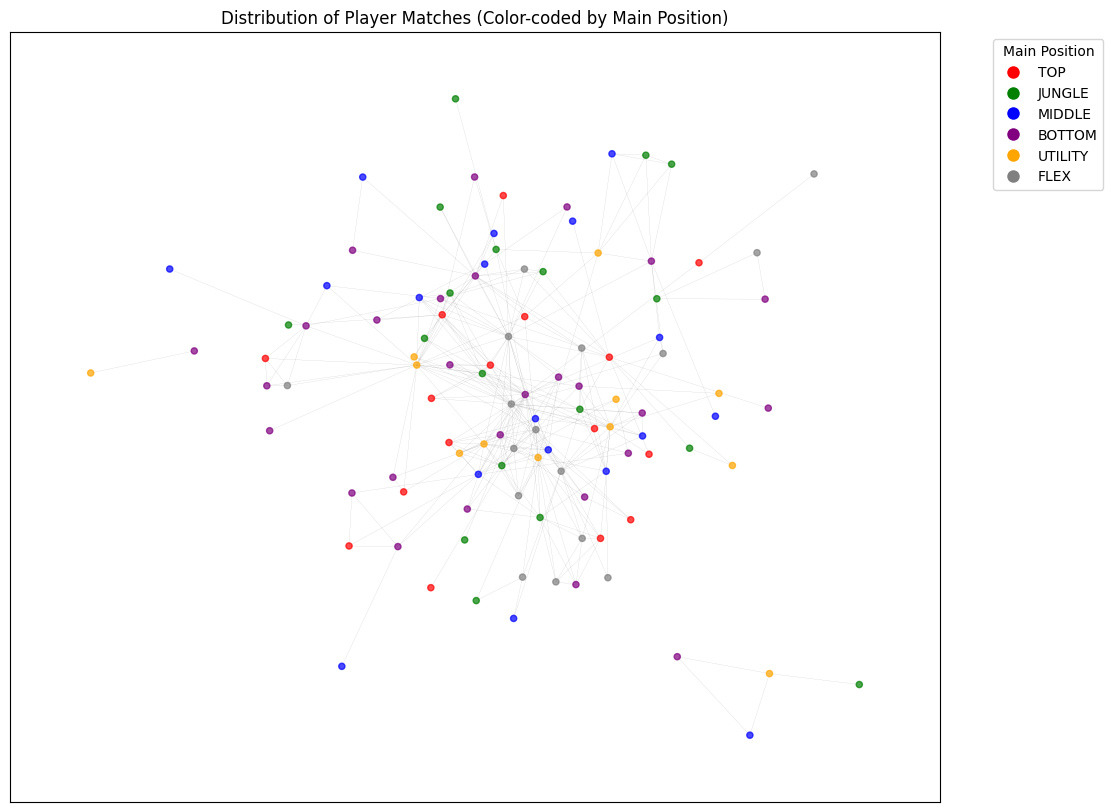

In [163]:
# Merge 'mainPosition' attribute into the graph nodes
main_position_map = player_data_with_centrality.set_index('puuid')['mainPosition'].to_dict()
nx.set_node_attributes(G, main_position_map, 'mainPosition')

# Remove isolated nodes (nodes with degree 0)
G_connected = G.copy()
# Create a list of nodes to remove (players with no games or mainPosition NaN)
no_match_or_no_position_players = [node for node, degree in dict(G_connected.degree()).items() if degree == 0 or 'mainPosition' not in G_connected.nodes[node] or pd.isna(G_connected.nodes[node]['mainPosition'])]
G_connected.remove_nodes_from(no_match_or_no_position_players)

# Define a color map for team positions
position_colors = {
    'TOP': 'red',
    'JUNGLE': 'green',
    'MIDDLE': 'blue',
    'BOTTOM': 'purple',
    'UTILITY': 'orange',
    'FLEX': 'gray'
}

# Get node colors based on 'mainPosition' attribute
node_colors = [position_colors.get(G_connected.nodes[node]['mainPosition'], 'black') for node in G_connected.nodes()]

# Set figure size
plt.figure(figsize=(12, 10))

# Compute positions for nodes using a spring layout for the connected graph
pos = nx.spring_layout(G_connected, k=0.15, iterations=20, seed=123)

# Draw the connected graph
nx.draw_networkx(
    G_connected,
    pos,
    with_labels=False,
    node_size=20,
    node_color=node_colors,
    width=0.1,
    alpha=0.7,
    edge_color='gray'
)

# Create a legend
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=pos, markerfacecolor=color, markersize=10)
                  for pos, color in position_colors.items()]
plt.legend(handles=legend_handles, title="Main Position", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Distribution of Player Matches (Color-coded by Main Position)')
plt.show()

Positions are very spread out. This makes sense since teams are supposed to be balanced in each match. The disconnected graphs are likely representative of players that only played one game that day which mostly had non-challenger players. Since that is a small amount of the data, it should have minimal effect on the graph's metrics.

In [164]:
# Drop any existing 'mainPosition' related columns from matches_with_centrality before merging (again)
columns_to_drop_from_matches = [col for col in matches_with_centrality.columns if 'mainPosition' in col]
if columns_to_drop_from_matches:
    matches_with_centrality = matches_with_centrality.drop(columns=columns_to_drop_from_matches)

matches_with_centrality = pd.merge(matches_with_centrality, player_data_with_centrality[['puuid', 'mainPosition']], on='puuid', how='left')
centrality_by_position_stats = matches_with_centrality.groupby('mainPosition')[['degree_centrality', 'eigenvector_centrality']].agg(['mean', 'median', 'std'])
centrality_by_position_stats

degree_centrality                     eigenvector_centrality  \
                          mean    median       std                   mean   
mainPosition                                                                
BOTTOM                0.071053  0.059701  0.058624               0.106083   
FLEX                  0.107363  0.104478  0.065207               0.173218   
JUNGLE                0.051782  0.044776  0.041673               0.081316   
MIDDLE                0.044300  0.029851  0.038382               0.067643   
TOP                   0.056775  0.052239  0.034910               0.071810   
UTILITY               0.088753  0.111940  0.063525               0.125576   

                                  
                median       std  
mainPosition                      
BOTTOM        0.066430  0.105524  
FLEX          0.180807  0.116065  
JUNGLE        0.072215  0.080005  
MIDDLE        0.042554  0.070672  
TOP           0.055401  0.054221  
UTILITY       0.124910  0.100522

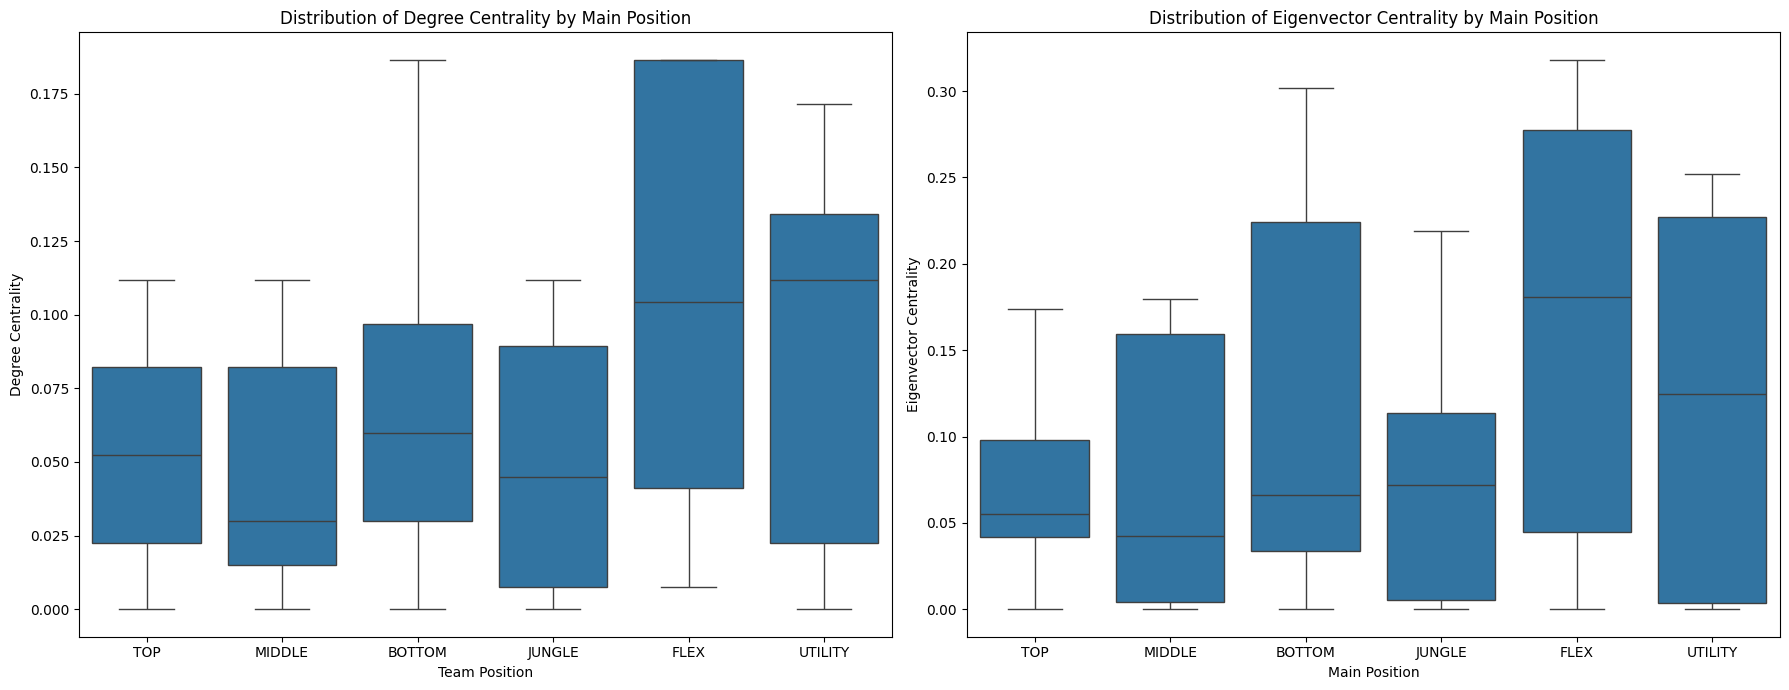

In [159]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Box plot for Degree Centrality by Main Position
sns.boxplot(x='mainPosition', y='degree_centrality', data=matches_with_centrality, ax=axes[0])
axes[0].set_title('Distribution of Degree Centrality by Main Position')
axes[0].set_xlabel('Team Position')
axes[0].set_ylabel('Degree Centrality')

# Box plot for Eigenvector Centrality by Main Position
sns.boxplot(x='mainPosition', y='eigenvector_centrality', data=matches_with_centrality, ax=axes[1])
axes[1].set_title('Distribution of Eigenvector Centrality by Main Position')
axes[1].set_xlabel('Main Position')
axes[1].set_ylabel('Eigenvector Centrality')

# Adjust layout to prevent overlapping titles and labels
plt.tight_layout()
plt.show()

**Degree centrality:**
Players primarily in the `FLEX` position show the highest mean degree centrality (0.107), followed by `UTILITY` (0.089). `MIDDLE` has the lowest mean. `FLEX` players also show the highest standard deviation (0.065), indicating a wider spread of degree centrality values within this group. This is understandable as they are collected from the other positions rather than strictly being their own position.

**Eigenvector centrality:**
`Flex` players also rank highest here in terms of mean and median. This somewhat is problematic for analysis because we wanted to compare the actual positions played more directly. However `UTILITY` players have strong eigenvector centrality which still indicates that they are strongly connected with other players. `MIDDLE` players show low eigenvector centrality, but the wide range implies some uncertainty. `TOP` is the lowest here (both on average and standard deviation) which indicates more certain results.

**Interpreting centrality in this data:** A player has a limited ability to choose teammates. Additionally, not everyone played the same amount of games. The comparisons here do imply that players who generally accommodate their teams the most, `FLEX` and `UTILITY` players, were the ones who played with the highest amount of players. Players have the ability to dodge games if they are unhappy with the team composition. This information does not exist for us to check. It is possible that the `FLEX` and `UTILITY` players had their attempted matches successfully start more often because of their flexibility.

Our hypothesis was on `JUNGLE` players being more proactive and accommodating. The low centrality values are surprising. However, it is possible that `FLEX` players were actually players who jungled a lot.

In [199]:
# Filter position_data for players whose mainPosition rate was less than 60%
low_rate_positions = position_data[(position_data['position_rate'] > 0.49) & (position_data['position_rate'] < 0.6)]

# Get the teamPosition for these players
common_roles_in_flex = low_rate_positions['teamPosition'].value_counts()

print("Most common teamPositions for players with < 60% overall position rate:")
print(common_roles_in_flex)

Most common teamPositions for players with < 60% overall position rate:
teamPosition
JUNGLE     9
MIDDLE     8
UTILITY    3
TOP        1
BOTTOM     1
Name: count, dtype: int64


Calculating players who played a role more than half of the time, but missed the cutoff for being considered flex, we see a lot of representation for `JUNGLE` and `MID`.

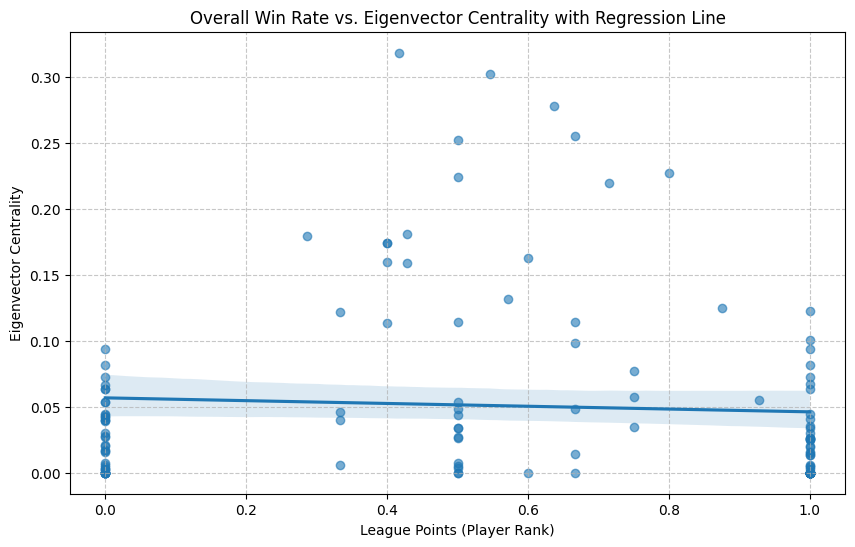

In [182]:
plt.figure(figsize=(10, 6))
sns.regplot(x='overall_win_rate', y='eigenvector_centrality', data=player_data_with_centrality, scatter_kws={'alpha':0.6})
plt.title('Overall Win Rate vs. Eigenvector Centrality with Regression Line')
plt.xlabel('Win rate')
plt.ylabel('Eigenvector Centrality')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

At a glance, win rate does not seem correlated with the strength of connections measured by eigenvector centrality. As matches were zero sum games between a mostly closed pool of players, this is actually appropriate.

In [206]:
dg_correlation_by_position = player_data_with_centrality.groupby('mainPosition').apply(lambda x: x['overall_win_rate'].corr(x['degree_centrality'], method='pearson'), include_groups=False)

print("Pearson correlation coefficient between overall_win_rate and degree_centrality by mainPosition:")
dg_correlation_by_position.sort_values(ascending=False)

Pearson correlation coefficient between overall_win_rate and degree_centrality by mainPosition:


,0
mainPosition,
FLEX,0.358210
TOP,0.012185
UTILITY,-0.021722
BOTTOM,-0.039240
JUNGLE,-0.136774
MIDDLE,-0.251475


In [186]:
correlation_by_position = player_data_with_centrality.groupby('mainPosition').apply(lambda x: x['overall_win_rate'].corr(x['eigenvector_centrality'], method='pearson'), include_groups=False)

print("Pearson correlation coefficient between overall_win_rate and eigenvector_centrality by mainPosition:")
correlation_by_position.sort_values(ascending=False)

Pearson correlation coefficient between overall_win_rate and eigenvector_centrality by mainPosition:


,0
mainPosition,
FLEX,0.397930
TOP,0.014929
JUNGLE,-0.061465
BOTTOM,-0.071764
UTILITY,-0.147533
MIDDLE,-0.209033


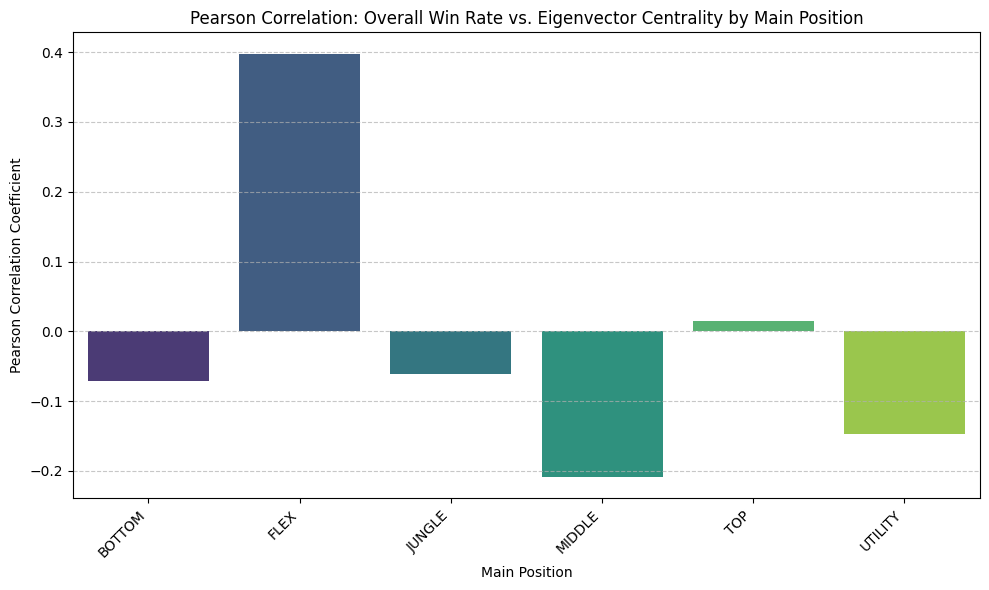

In [190]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_by_position.index, y=correlation_by_position.values, hue=correlation_by_position.index, palette='viridis', legend=False)
plt.title('Pearson Correlation: Overall Win Rate vs. Eigenvector Centrality by Main Position')
plt.xlabel('Main Position')
plt.ylabel('Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Correlating win rate against each position's eigenvector provides more actionable results. `FLEX` shows the only strong correlation here. Players that were more willing to play multiple roles when faced with a higher number of unique teammates won more often. It appears that defaulting to `JUNGLE` or even `UTILITY` was not a free ticket on its own to winning more as both positions showed negative correlations.

In [203]:
correlation_on_my_way = player_data_with_centrality['overall_win_rate'].corr(player_data_with_centrality['avg_onMyWayPings'], method='pearson')
correlation_fist_bump = player_data_with_centrality['overall_win_rate'].corr(player_data_with_centrality['avg_fistBumpParticipation'], method='pearson')

print(f'Pearson correlation between overall_win_rate and avg_onMyWayPings: {correlation_on_my_way:.3f}')
print(f'Pearson correlation between overall_win_rate and avg_fistBumpParticipation: {correlation_fist_bump:.3f}')

Pearson correlation between overall_win_rate and avg_onMyWayPings: 0.170
Pearson correlation between overall_win_rate and avg_fistBumpParticipation: 0.036


A theory we had was that participating in actions with a player's team would increase win likelihood. This correlation appears low. We can delve deeper with a t-test based on categorical versions of these counts. This would pit players who ever participated in either action against the ones who abstained every game.

In [209]:
player_data_with_centrality['fistBumpGroup'] = player_data_with_centrality['avg_fistBumpParticipation'].apply(lambda x: 'Fist Bumps' if x > 0 else 'No Fist Bumps')

# Separate data into two groups based on fistBumpGroup
fist_bump_group = player_data_with_centrality[player_data_with_centrality['fistBumpGroup'] == 'Fist Bumps']['overall_win_rate']
no_fist_bump_group = player_data_with_centrality[player_data_with_centrality['fistBumpGroup'] == 'No Fist Bumps']['overall_win_rate']

# t-test
t_statistic, p_value = stats.ttest_ind(fist_bump_group, no_fist_bump_group, equal_var=False) # Assuming unequal variances

print(f'T-statistic: {t_statistic:.3f}')
print(f'P-value: {p_value:.3f}')

T-statistic: 0.869
P-value: 0.391


**T-statistic**: 0.869
**P-value**: 0.391

The null hypothesis is that there is no significant difference in winrate for players that used the fist bump emote. We do not reject the null hypothesis because the P-value is well above the 0.05 threshold.

In [212]:
player_data_with_centrality['OMWGroup'] = player_data_with_centrality['avg_onMyWayPings'].apply(lambda x: 'Ping' if x > 0 else 'No Ping')

# Separate data into two groups based on omwgroup
omw_group = player_data_with_centrality[player_data_with_centrality['OMWGroup'] == 'Ping']['overall_win_rate']
no_omw_group = player_data_with_centrality[player_data_with_centrality['OMWGroup'] == 'No Ping']['overall_win_rate']

# t-test
t_statistic, p_value = stats.ttest_ind(omw_group, no_omw_group, equal_var=False) # Assuming unequal variances

print(f'T-statistic: {t_statistic:.3f}')
print(f'P-value: {p_value:.3f}')

T-statistic: 0.712
P-value: 0.549


**T-statistic**: 0.712
**P-value**: 0.549

Likewise, the null hypothesis is that there is no significant difference in winrate for players that used the on my way ping. We do not reject the null hypothesis because the P-value is well above the 0.05 threshold. This result is more surprising because pings are used for communication which is important for a team based game.

## Conclusions

There is a lot to unpack about the results. On their own, the centrality measures (degree and eigenvector) were not indicative of connectivity in the way they may seem. The reason was that the edges, the games played, would've been better suited as a multigraph. The choice of limiting the dataset to a single Challenger tier caused a lot of the player overlap. It increased the likelihood of a pool of players that would match with each other, thus create an edge, but also the chances that it would happen multiple times. A node's connectivity was a combination of play rate (total number of games) and chance (queuing into different teammates versus getting the same ones every game). Count data was less useful than rate data since a node could have abnormally high counts if a lot of games were played. Ultimately, the data could still be used for analysis as long as care was taken to account for these situations.

We sought to use network analysis to determine what factors impacted win rates. Initially, we believed that:

*  `JUNGLE` players would win more often because their position requires teamwork by design.
*  Having higher connections would lead to more wins.
*  In-game teamwork actions (pings, emotes) would correlate with more wins.

Every hypothesis had a flaw in the end:
*  `FLEX` players, a group that did consist of a lot of players that chose `JUNGLE` often, instead had the best winrates when centrality measures were high. When faced with more unique teammates, they were the most likely to adapt and win. This implies that maybe `JUNGLE` mains that were less willing to adapt clashed with their teams and hurt their winrates compared to those who conceded.
*  Connections measured by centrality measures did not provide strong conclusive data without further context.
*  In-game teamwork actions did not show a strong correlation with winning more. As all players analyzed were Challenger tier, it is possible that these actions have already stabilized in usage.

It appears that a Challenger player's communication skills are already baked into their ability to win and stay at the top tier. It does not affect their win rates that much when we look at their in-game performance. However, their ability to accommodate others before a game even starts by being position flexible is a better show of evidence of their teamwork leading to more wins.

This presentation recording can be found at: https://youtu.be/uyxpIN3Hf_w

